### Imports

In [528]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator 

### Parameters (From Seed Paper)

In [529]:
# w1, w2, w3 are hormone removal rates
w1 = 0.17
w2 = 0.035
w3 = 0.0086
wC = np.log(2) / (7 * 24 * 60) # 7 day half life
wA = np.log(2) / (14 * 24 * 60) # 14 day half life
n  = 3 # Hill coefficient

D_stress = 30
D_stop = 120
tau      = 2000 # GR recovery constant

In [530]:
# inputs: x3 (cortisol), pGR_val  = pGR(t)
def f_hill(x3, pGR_val):
    return 1.0 / (1.0 + (x3 / pGR_val) ** n)

# dynamic GR feedback
def pGR(t):
    t_days = t / 1440
    phase = "chronic" if t_days >=D_stress else "healthy"
    # Phase: healthy
    if t_days < D_stress:
        return 5.0
    # Phase: chronic pulse input
    elif D_stress <= t_days <= D_stop:
        return 5.0
    # Phase: recovery
    else:
        # Exponential recovery from 5 back to 2
        return 2.0 + 3.0 * np.exp(-(t - D_stop*1440) / tau)

# pulse input u(t) that lasts for a few weeks, shows elevated hormones during the stress, and a return to baseline within hours after the stress is over
# baseline u = 1, then pulse input (u=4) lasting 3 months, then return to baseline (u=1)
def u(t):
    t_days = t / 1440
    phase = "chronic" if t_days >=D_stress else "healthy"
    
    if phase == "healthy":
        return 1.0 
    elif phase == "chronic":
        if t_days <= D_stop:     # Chronic Stress Phase
            return 4.0
        else:                # Recovery Phase
            return 1

In [531]:
def hpa_model(y, t):
    x1, x2, x3, C, A = y
    
    u_t = u(t)
    K_t = pGR(t)
    
    # GR feedback
    G_x3 = 1.0 / (1.0 + (x3 / K_t)**n)

    # MR feedback
    M_x3 = 1.0 / x3

    g1 = G_x3 * M_x3
    g2 = G_x3
    
    # Differential Equations
    dx1 = w1 * (u_t * g1 - x1)
    dx2 = w2 * (C * x1 * g2 - x2)
    dx3 = w3 * (A * x2 - x3)
    dC  = wC * C * (x1 - 1.0) 
    dA  = wA * A * (x2  - 1.0) 
    
    return [dx1, dx2, dx3, dC, dA]

In [532]:
t_days = 200 # timescale of 200 days
t_eval = np.linspace(0, t_days * 1440, 10000)
y0 = [1.0, 1.0, 1.0, 1.0, 1.0] # initial conditions

# Run simulations
sol = odeint(hpa_model, y0, t_eval, args=())


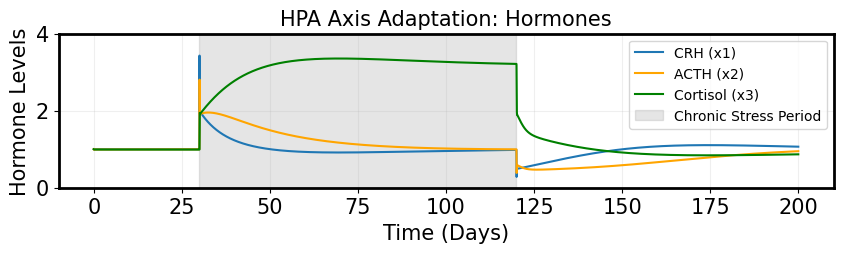

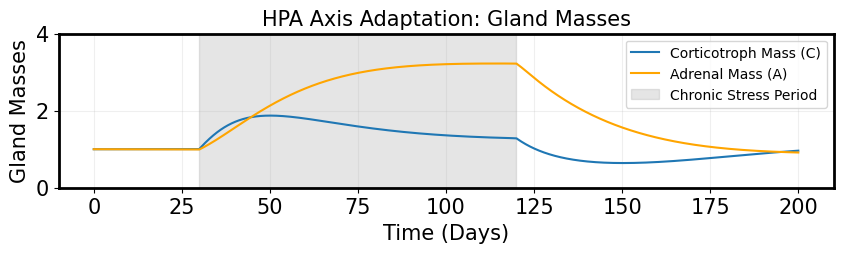

Gland mass at steady state   | C: 0.9624 | A: 0.9146


In [533]:
# plotting
plt.figure(figsize=(10, 2))
plt.plot(t_eval/1440, sol[:, 0], label='CRH (x1)', color='tab:blue')
plt.plot(t_eval/1440, sol[:, 1], label='ACTH (x2)', color='orange')
plt.plot(t_eval/1440, sol[:, 2], label='Cortisol (x3)', color='green')
plt.axvspan(D_stress, D_stop, color='gray', alpha=0.2, label='Chronic Stress Period')
plt.title("HPA Axis Adaptation: Hormones")
plt.xlabel("Time (Days)")
plt.ylabel("Hormone Levels")
plt.ylim(0, 4)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(t_eval/1440, sol[:, 3], label='Corticotroph Mass (C)', color='tab:blue')
plt.plot(t_eval/1440, sol[:, 4], label='Adrenal Mass (A)', color='orange')
plt.axvspan(D_stress, D_stop, color='gray', alpha=0.2, label='Chronic Stress Period')
plt.title("HPA Axis Adaptation: Gland Masses")
plt.xlabel("Time (Days)")
plt.ylabel("Gland Masses")
plt.legend()
plt.ylim(0, 4)
plt.grid(alpha=0.2)
plt.show()

# Extract the final values (Index -1 is the last day, which is 200)
c_ss = sol[-1, 3]
a_ss = sol[-1, 4]

print(f"Gland mass at steady state   | C: {c_ss:.4f} | A: {a_ss:.4f}")

# Novel Extension: Melatonin-Modulated GR Resistance

In [534]:
# Novel Extension: Melatonin-Modulated GR Resistance
# --- 1. NORMAL STATE (CONT + NaCl vs CONT + MEL) ---
# Format: [NaCl, MEL]
kd_norm_hp = {
    "hypo": [9.8, 26.9], 
    "pit": [2.2, 10.4]
}
bmax_norm_hp = {
    "hypo": [15.5, 53.1], 
    "pit": [8.2, 20.3]
}

# --- 2. CHRONIC STRESS STATE (CS + NaCl vs CS + MEL) ---
kd_stress_hp = {
    "hypo": [13.7, 16.5], 
    "pit": [2.5, 4.1]
}
bmax_stress_hp = {
    "hypo": [17.6, 19.3], 
    "pit": [16.6, 9.3]
}

# Helper to get the average ratio for Hypo and Pit
def get_hp_ratios(data_dict):
    return np.mean([v[1]/v[0] for v in data_dict.values()])

# KD MODIFIERS (Higher = Lower Affinity/Higher Threshold)
avg_kd_normal_hp = get_hp_ratios(kd_norm_hp)
avg_kd_stress_hp = get_hp_ratios(kd_stress_hp)

# BMAX MODIFIERS (Higher = More Receptors)
avg_bmax_normal_hp = get_hp_ratios(bmax_norm_hp)
avg_bmax_stress_hp = get_hp_ratios(bmax_stress_hp)

print(f"--- Hypo-Pit Normal --- \nKd: {avg_kd_normal_hp:.2f}, Bmax: {avg_bmax_normal_hp:.2f}")
print(f"--- Hypo-Pit Stressed --- \nKd: {avg_kd_stress_hp:.2f}, Bmax: {avg_bmax_stress_hp:.2f}")

--- Hypo-Pit Normal --- 
Kd: 3.74, Bmax: 2.95
--- Hypo-Pit Stressed --- 
Kd: 1.42, Bmax: 0.83


In [535]:
x3_threshold = (0.9624  * 0.9146)**(1/2) # # quasi steady state concentration of cortisol at healthy adrenal mass and corticotroph mass levels = (CA)^(1/2) = 1 

MEL_active = True 

def pGR_melatonin(x3, t, mel_on=True):
    """
    x3: Current Cortisol concentration from the ODE solver
    mel_active: Boolean to toggle the melatonin effect
    """
    t_days = t / 1440

    mel_modifier = 1

    if(mel_on):
        if x3 > x3_threshold:
            mel_modifier = avg_kd_stress_hp # avg_kd_low # melatonin effect when cortisol is high
        else:
            mel_modifier = avg_kd_normal_hp # avg_kd_high # melatonin effect when cortisol is low/normal

    # Phase: healthy
    if t_days < D_stress:
        return 5.0 * mel_modifier
    # Phase: chronic pulse input
    elif D_stress <= t_days <= D_stop:  
        return 5.0 * mel_modifier
    # Phase: recovery
    else:
        # Exponential recovery from 5 back to 2
        return (2.0 * mel_modifier + 3.0 * mel_modifier * np.exp(-(t - D_stop*1440) / tau))

In [536]:

def hpa_model_mel(y, t, mel_on):
    x1, x2, x3, C, A = y
    u_t = u(t)
    
    # K_t (G_x3 sensitivity coefficient) is based on concentration of cortisol
    K_t = pGR_melatonin(x3, t, mel_on=mel_on)
    t_days = t / 1440
    
    # Melatonin decreases density of glucocorticoid receptors
    receptor_density = 1.0 

    if mel_on and x3 > x3_threshold:
        receptor_density *= avg_bmax_stress_hp
    elif mel_on:
        receptor_density *= avg_bmax_normal_hp
    
    n = 3 

    G_x3 = receptor_density / (1.0 + (x3 / K_t)**n)
    
    # Standard 1/x3 feedback term for the Hypothalamus
    M_x3 = 1.0 / x3
    
    # 4. ODE Equations
    dx1 = w1 * (u_t * G_x3 * M_x3 - x1)
    dx2 = w2 * (C * x1 * G_x3 - x2)
    dx3 = w3 * (A * x2 - x3)
    
    # Gland Mass Growth/Shrinkage (Slow timescales)
    dC  = wC * C * (x1 - 1.0)
    dA  = wA * A * (x2 - 1.0)
    
    return [dx1, dx2, dx3, dC, dA]

t_eval = np.linspace(0, 250 * 1440, 10000)
y0 = [1.0, 1.0, 1.0, 1.0, 1.0]

sol_control = odeint(hpa_model_mel, y0, t_eval, args=(False,))
sol_mel = odeint(hpa_model_mel, y0, t_eval, args=(True,))

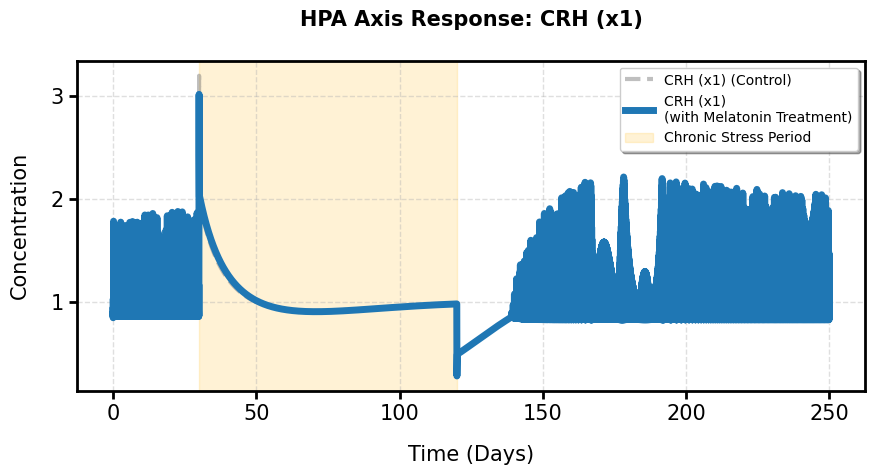

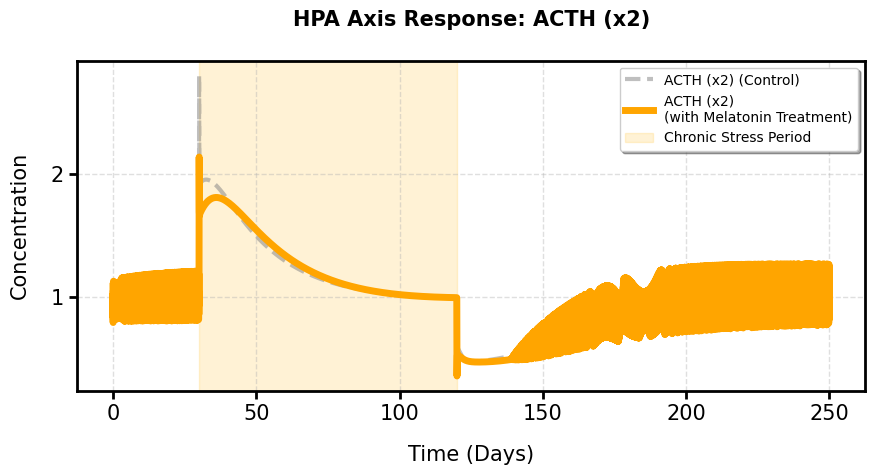

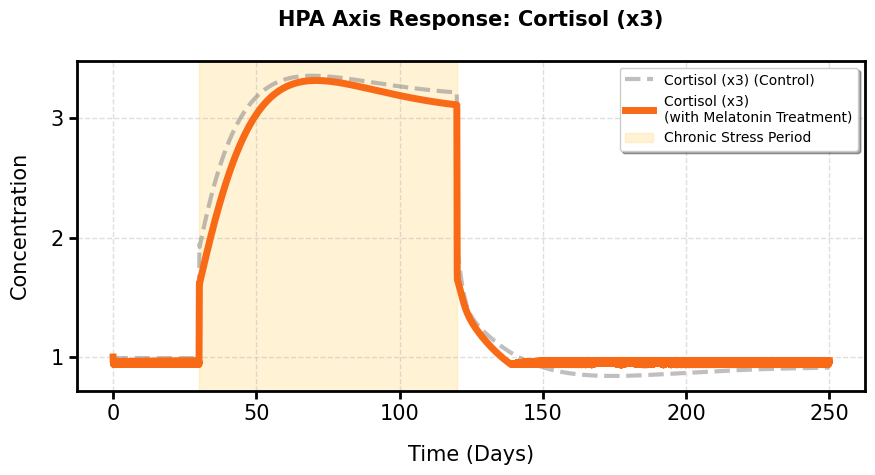

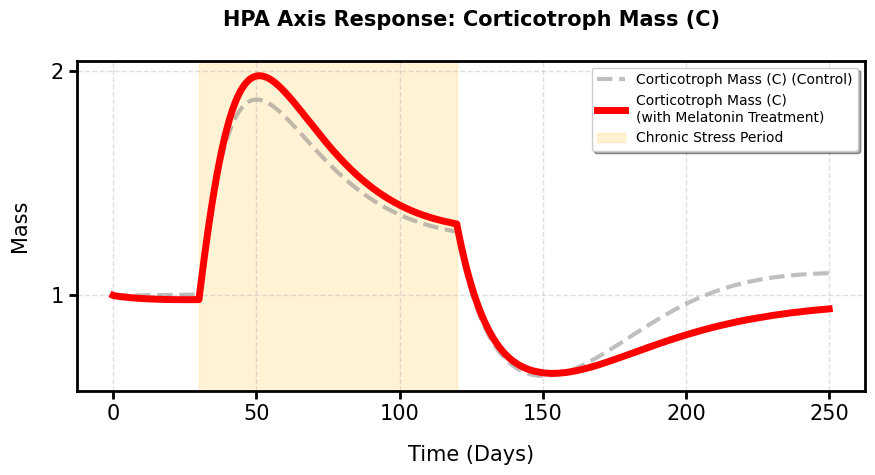

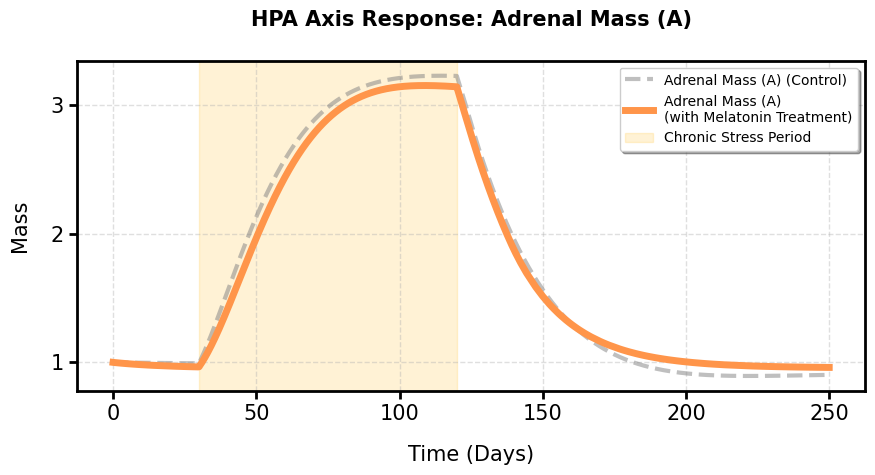

In [537]:
# High-visibility settings for poster printing
plt.rcParams.update({
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'legend.fontsize': 10,
    'axes.linewidth': 2  # Thicker plot border
})

labels = ['CRH (x1)', 'ACTH (x2)', 'Cortisol (x3)', 'Corticotroph Mass (C)', 'Adrenal Mass (A)']
colors = ['tab:blue', 'orange', '#F96A17', 'red', '#FF954A']

for i in range(5):
    # Large, wide figure for poster layout
    plt.figure(figsize=(9, 5))

    # Plot Control (Increased linewidth and alpha for visibility)
    plt.plot(t_eval/1440, sol_control[:, i],
             label=f'{labels[i]} (Control)',
             color='gray', linestyle='--', alpha=0.5, linewidth=3)

    # Plot Melatonin (Very thick line for the main result)
    plt.plot(t_eval/1440, sol_mel[:, i],
             label=f'{labels[i]}\n(with Melatonin Treatment)',
             color=colors[i], linewidth=5)

    # Shade the stress period (Slightly darker for print contrast)
    plt.axvspan(D_stress, D_stop, color="#FFC12F", alpha=0.2, label='Chronic Stress Period')

    # Formatting
    plt.title(f"HPA Axis Response: {labels[i]}", pad=25, fontweight='bold')
    y_label = "Concentration"
    if "Mass" in labels[i]:
        y_label = "Mass"

    plt.ylabel(y_label, labelpad=15)
    plt.xlabel("Time (Days)", labelpad=15)

    # Force whole numbers on Y-axis
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

    # Make the tick marks thicker
    plt.gca().tick_params(width=2, length=6)

    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(alpha=0.4, linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()